DATASET LOADED SUCCESSFULLY
Number of Rows    : 180519
Number of Columns : 53

First 5 records:
       Type  Days for shipping (real)  Days for shipment (scheduled)  \
0     DEBIT                         3                              4   
1  TRANSFER                         5                              4   
2      CASH                         4                              4   
3     DEBIT                         3                              4   
4   PAYMENT                         2                              4   

   Benefit per order  Sales per customer   Delivery Status  \
0          91.250000          314.640015  Advance shipping   
1        -249.089996          311.359985     Late delivery   
2        -247.779999          309.720001  Shipping on time   
3          22.860001          304.809998  Advance shipping   
4         134.210007          298.250000  Advance shipping   

   Late_delivery_risk  Category Id   Category Name Customer City  ...  \
0                   0    

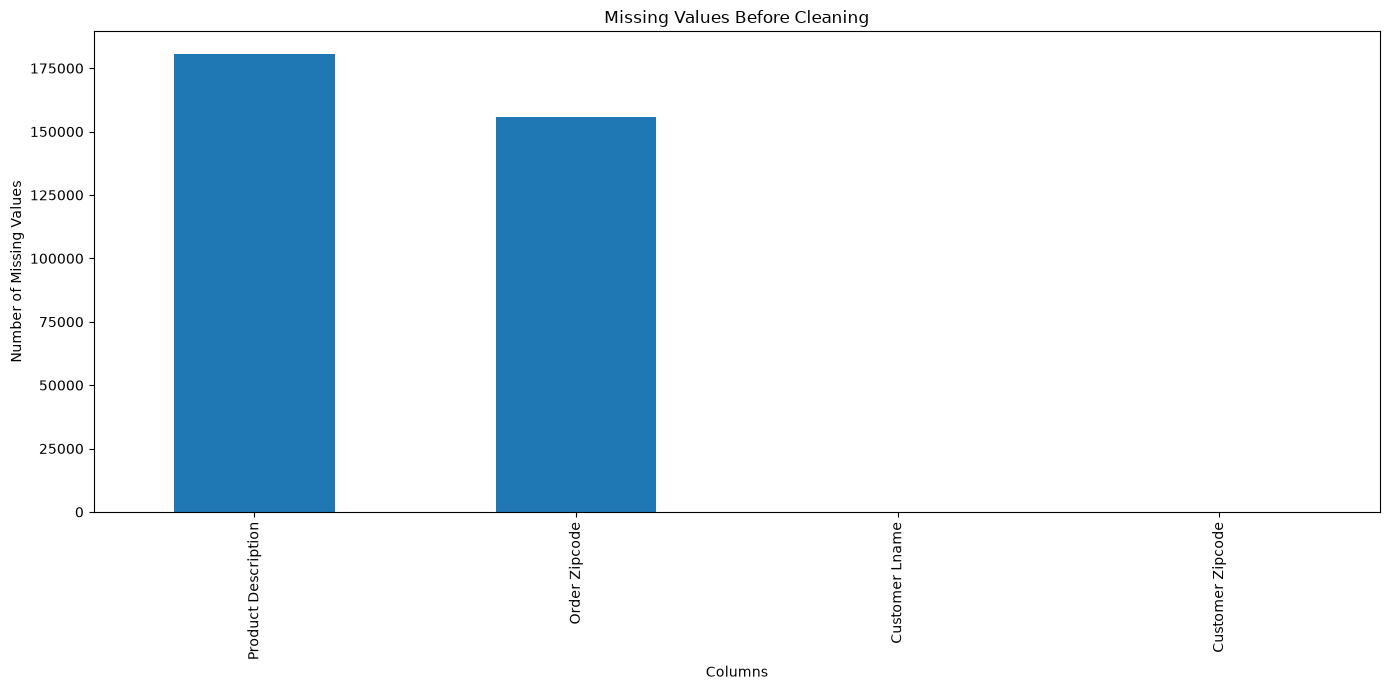


DUPLICATE RECORDS
Duplicate rows found: 0
Duplicate rows after removal: 0

CLEANED COLUMN NAMES
['type', 'days_for_shipping_real', 'days_for_shipment_scheduled', 'benefit_per_order', 'sales_per_customer', 'delivery_status', 'late_delivery_risk', 'category_id', 'category_name', 'customer_city', 'customer_country', 'customer_email', 'customer_fname', 'customer_id', 'customer_lname', 'customer_password', 'customer_segment', 'customer_state', 'customer_street', 'customer_zipcode', 'department_id', 'department_name', 'latitude', 'longitude', 'market', 'order_city', 'order_country', 'order_customer_id', 'order_date_dateorders', 'order_id', 'order_item_cardprod_id', 'order_item_discount', 'order_item_discount_rate', 'order_item_id', 'order_item_product_price', 'order_item_profit_ratio', 'order_item_quantity', 'sales', 'order_item_total', 'order_profit_per_order', 'order_region', 'order_state', 'order_status', 'order_zipcode', 'product_card_id', 'product_category_id', 'product_description', '

C:\Users\Aashish Thakur\AppData\Local\Temp\ipykernel_29636\4179151493.py:237: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(


customer_lname: 8 missing values filled using mode.

CHECKING INVALID VALUES
Negative quantities: 0
Negative sales: 0

OUTLIER DETECTION
benefit_per_order: 18942 outliers
sales_per_customer: 1943 outliers
customer_id: 1198 outliers
department_id: 362 outliers
latitude: 9 outliers
longitude: 1414 outliers
order_customer_id: 1198 outliers
order_item_discount: 7537 outliers
order_item_product_price: 2048 outliers
order_item_profit_ratio: 17300 outliers
sales: 488 outliers
order_item_total: 1943 outliers
order_profit_per_order: 18942 outliers
order_zipcode: 24818 outliers
product_price: 2048 outliers
delay_days: 35701 outliers


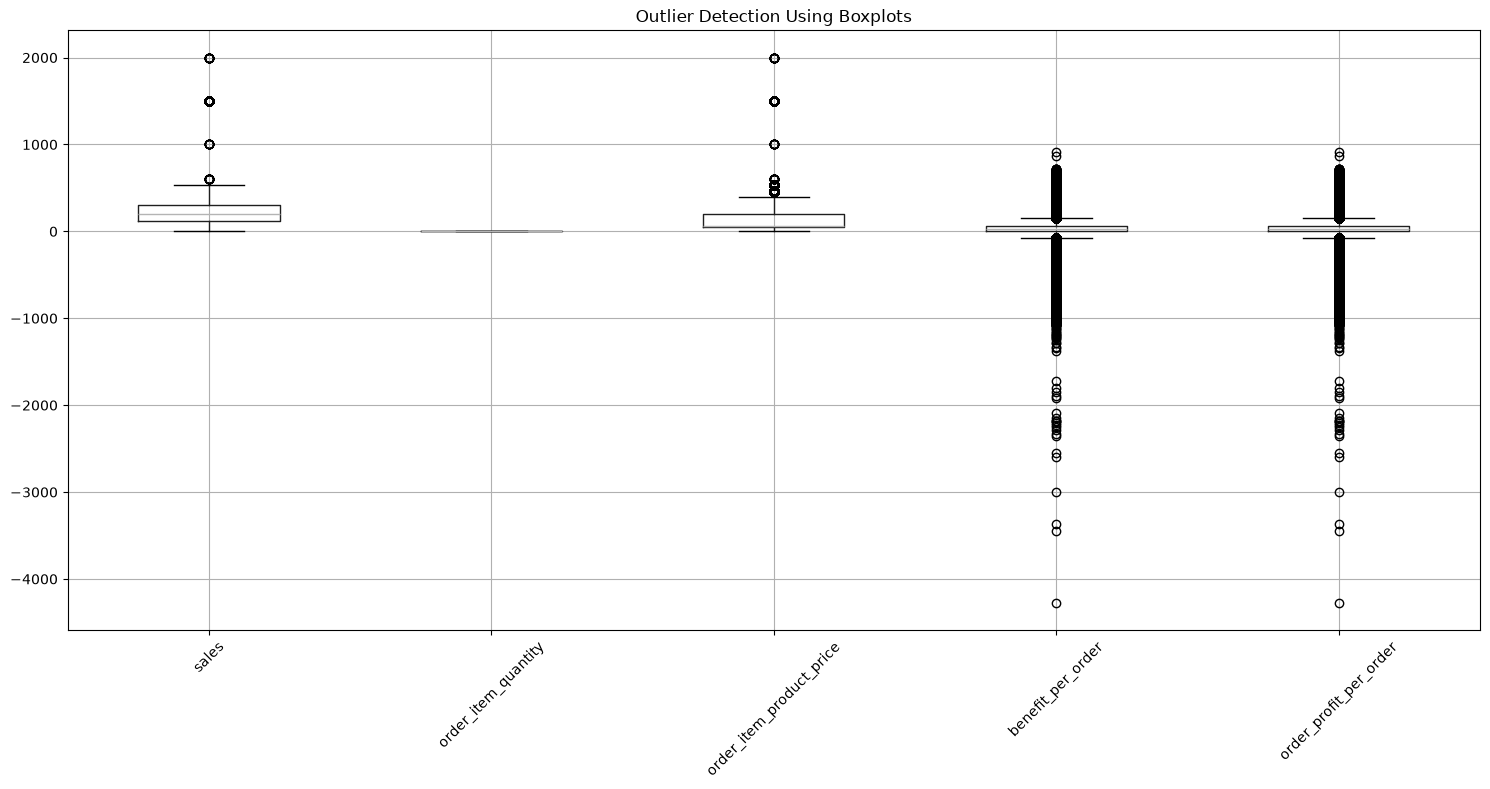


HANDLING OUTLIERS
Outliers handled using IQR capping.

NORMALIZATION / STANDARDIZATION
Standardization completed for:
['days_for_shipping_real', 'days_for_shipment_scheduled', 'benefit_per_order', 'sales_per_customer', 'order_item_discount', 'order_item_discount_rate', 'order_item_product_price', 'order_item_profit_ratio', 'order_item_quantity', 'sales', 'order_item_total', 'order_profit_per_order', 'product_price']

FINAL DATA QUALITY CHECK
Final Rows: 180519
Final Columns: 57
Missing Values: 180519
Duplicate Rows: 0


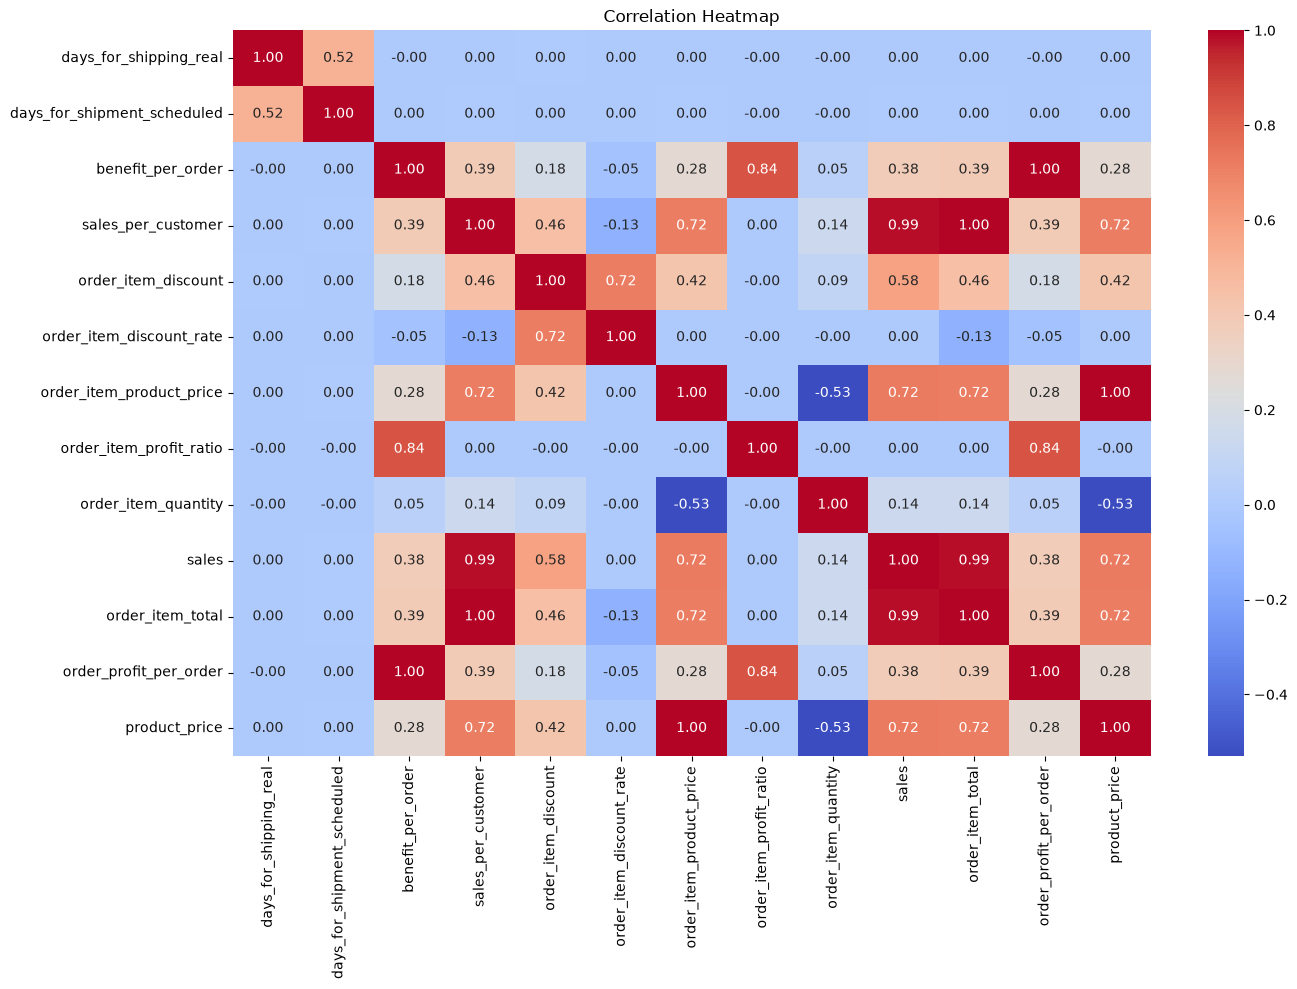


PROCESSED DATASET SAVED
File created: cleaned_logistics_data.csv

Preprocessing Summary:
                     Metric                 Value
0             Original Rows  Check initial output
1          Original Columns  Check initial output
2        Duplicates Removed                     0
3                Final Rows                180519
4             Final Columns                    57
5  Missing Values Remaining                180519
6  Duplicate Rows Remaining                     0
7     Features Standardized                    13

LOGISTICS DATA PREPROCESSING COMPLETED


In [1]:
# ============================================================
# LOGISTICS DATA PREPROCESSING PROJECT
# DataCo Smart Supply Chain Dataset
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler


# ============================================================
# 1. LOAD DATASET
# ============================================================

file_path = "DataCoSupplyChainDataset.csv"

df = pd.read_csv(
    file_path,
    encoding="latin1"
)

print("=" * 70)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 70)

print("Number of Rows    :", df.shape[0])
print("Number of Columns :", df.shape[1])

print("\nFirst 5 records:")
print(df.head())


# ============================================================
# 2. BASIC DATA EXPLORATION
# ============================================================

print("\n" + "=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()


# ============================================================
# 3. CHECK MISSING VALUES
# ============================================================

print("\n" + "=" * 70)
print("MISSING VALUES")
print("=" * 70)

missing_values = df.isnull().sum()

missing_values = missing_values[
    missing_values > 0
].sort_values(
    ascending=False
)

print(missing_values)


# ============================================================
# 4. VISUALIZE MISSING VALUES
# ============================================================

if len(missing_values) > 0:

    plt.figure(figsize=(14, 7))

    missing_values.plot(
        kind="bar"
    )

    plt.title(
        "Missing Values Before Cleaning"
    )

    plt.xlabel("Columns")
    plt.ylabel("Number of Missing Values")

    plt.xticks(rotation=90)

    plt.tight_layout()

    plt.savefig(
        "missing_values_before.png",
        dpi=300
    )

    plt.show()


# ============================================================
# 5. CHECK DUPLICATE RECORDS
# ============================================================

print("\n" + "=" * 70)
print("DUPLICATE RECORDS")
print("=" * 70)

duplicates = df.duplicated().sum()

print(
    "Duplicate rows found:",
    duplicates
)

# Remove duplicate rows
df = df.drop_duplicates()

print(
    "Duplicate rows after removal:",
    df.duplicated().sum()
)


# ============================================================
# 6. CLEAN COLUMN NAMES
# ============================================================

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace("-", "_")
)

print("\n" + "=" * 70)
print("CLEANED COLUMN NAMES")
print("=" * 70)

print(df.columns.tolist())


# ============================================================
# 7. CONVERT DATE COLUMNS
# ============================================================

print("\n" + "=" * 70)
print("DATE CONVERSION")
print("=" * 70)

date_columns = [
    "order_date_dateorders",
    "shipping_date_dateorders"
]

for column in date_columns:

    if column in df.columns:

        df[column] = pd.to_datetime(
            df[column],
            errors="coerce"
        )

        print(
            f"{column} converted to datetime."
        )


# ============================================================
# 8. CREATE LOGISTICS DELAY FEATURE
# ============================================================

print("\n" + "=" * 70)
print("CREATING DELAY FEATURE")
print("=" * 70)

df["delay_days"] = (
    df["days_for_shipping_real"]
    -
    df["days_for_shipment_scheduled"]
)

print(
    df[
        [
            "days_for_shipping_real",
            "days_for_shipment_scheduled",
            "delay_days"
        ]
    ].head()
)


# ============================================================
# 9. CREATE ORDER MONTH FEATURE
# ============================================================

if "order_date_dateorders" in df.columns:

    df["order_month"] = (
        df["order_date_dateorders"]
        .dt.month
    )

    df["order_year"] = (
        df["order_date_dateorders"]
        .dt.year
    )

    df["order_day"] = (
        df["order_date_dateorders"]
        .dt.day
    )


# ============================================================
# 10. HANDLE MISSING VALUES
# ============================================================

print("\n" + "=" * 70)
print("HANDLING MISSING VALUES")
print("=" * 70)

# Numerical columns
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

# Categorical columns
categorical_columns = df.select_dtypes(
    include=["object"]
).columns


# Numerical → Median
for column in numerical_columns:

    missing_count = df[column].isnull().sum()

    if missing_count > 0:

        median_value = df[column].median()

        df[column] = df[column].fillna(
            median_value
        )

        print(
            f"{column}: {missing_count} missing values "
            f"filled using median."
        )


# Categorical → Mode
for column in categorical_columns:

    missing_count = df[column].isnull().sum()

    if missing_count > 0:

        mode_value = df[column].mode()

        if len(mode_value) > 0:

            df[column] = df[column].fillna(
                mode_value.iloc[0]
            )

            print(
                f"{column}: {missing_count} missing values "
                f"filled using mode."
            )


# ============================================================
# 11. CHECK INVALID NUMERICAL VALUES
# ============================================================

print("\n" + "=" * 70)
print("CHECKING INVALID VALUES")
print("=" * 70)

# Quantity should not be negative
if "order_item_quantity" in df.columns:

    invalid_quantity = (
        df["order_item_quantity"] < 0
    ).sum()

    print(
        "Negative quantities:",
        invalid_quantity
    )


# Sales should normally not be negative
if "sales" in df.columns:

    invalid_sales = (
        df["sales"] < 0
    ).sum()

    print(
        "Negative sales:",
        invalid_sales
    )


# ============================================================
# 12. OUTLIER DETECTION USING IQR
# ============================================================

print("\n" + "=" * 70)
print("OUTLIER DETECTION")
print("=" * 70)

outlier_summary = {}

for column in numerical_columns:

    Q1 = df[column].quantile(0.25)

    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR

    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_limit)
        |
        (df[column] > upper_limit)
    ]

    outlier_summary[column] = len(
        outliers
    )


for column, count in outlier_summary.items():

    if count > 0:

        print(
            f"{column}: {count} outliers"
        )


# ============================================================
# 13. VISUALIZE IMPORTANT OUTLIERS
# ============================================================

important_columns = [
    "sales",
    "order_item_quantity",
    "order_item_product_price",
    "benefit_per_order",
    "order_profit_per_order"
]

available_columns = [
    column
    for column in important_columns
    if column in df.columns
]

if len(available_columns) > 0:

    plt.figure(
        figsize=(15, 8)
    )

    df[
        available_columns
    ].boxplot()

    plt.title(
        "Outlier Detection Using Boxplots"
    )

    plt.xticks(
        rotation=45
    )

    plt.tight_layout()

    plt.savefig(
        "outliers_before.png",
        dpi=300
    )

    plt.show()


# ============================================================
# 14. HANDLE OUTLIERS USING IQR CAPPING
# ============================================================

print("\n" + "=" * 70)
print("HANDLING OUTLIERS")
print("=" * 70)

for column in numerical_columns:

    Q1 = df[column].quantile(0.25)

    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR

    upper_limit = Q3 + 1.5 * IQR

    # Cap values instead of deleting rows
    df[column] = np.clip(
        df[column],
        lower_limit,
        upper_limit
    )

print(
    "Outliers handled using IQR capping."
)


# ============================================================
# 15. SELECT FEATURES FOR NORMALIZATION
# ============================================================

features_to_scale = [
    "days_for_shipping_real",
    "days_for_shipment_scheduled",
    "benefit_per_order",
    "sales_per_customer",
    "order_item_discount",
    "order_item_discount_rate",
    "order_item_product_price",
    "order_item_profit_ratio",
    "order_item_quantity",
    "sales",
    "order_item_total",
    "order_profit_per_order",
    "product_price"
]

features_to_scale = [
    column
    for column in features_to_scale
    if column in df.columns
]


# ============================================================
# 16. STANDARDIZATION
# ============================================================

print("\n" + "=" * 70)
print("NORMALIZATION / STANDARDIZATION")
print("=" * 70)

scaler = StandardScaler()

df[
    features_to_scale
] = scaler.fit_transform(
    df[features_to_scale]
)

print(
    "Standardization completed for:"
)

print(
    features_to_scale
)


# ============================================================
# 17. CHECK FINAL DATA QUALITY
# ============================================================

print("\n" + "=" * 70)
print("FINAL DATA QUALITY CHECK")
print("=" * 70)

print(
    "Final Rows:",
    df.shape[0]
)

print(
    "Final Columns:",
    df.shape[1]
)

print(
    "Missing Values:",
    df.isnull().sum().sum()
)

print(
    "Duplicate Rows:",
    df.duplicated().sum()
)


# ============================================================
# 18. CORRELATION HEATMAP
# ============================================================

correlation_columns = [
    column
    for column in features_to_scale
    if column in df.columns
]

if len(correlation_columns) > 1:

    plt.figure(
        figsize=(14, 10)
    )

    correlation_matrix = df[
        correlation_columns
    ].corr()

    sns.heatmap(
        correlation_matrix,
        annot=True,
        fmt=".2f",
        cmap="coolwarm"
    )

    plt.title(
        "Correlation Heatmap"
    )

    plt.tight_layout()

    plt.savefig(
        "correlation_heatmap.png",
        dpi=300
    )

    plt.show()


# ============================================================
# 19. SAVE PROCESSED DATASET
# ============================================================

output_file = (
    "cleaned_logistics_data.csv"
)

df.to_csv(
    output_file,
    index=False
)

print("\n" + "=" * 70)
print("PROCESSED DATASET SAVED")
print("=" * 70)

print(
    f"File created: {output_file}"
)


# ============================================================
# 20. CREATE SUMMARY REPORT
# ============================================================

summary = pd.DataFrame({

    "Metric": [
        "Original Rows",
        "Original Columns",
        "Duplicates Removed",
        "Final Rows",
        "Final Columns",
        "Missing Values Remaining",
        "Duplicate Rows Remaining",
        "Features Standardized"
    ],

    "Value": [
        "Check initial output",
        "Check initial output",
        duplicates,
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        len(features_to_scale)
    ]

})

summary.to_csv(
    "preprocessing_summary.csv",
    index=False
)

print("\nPreprocessing Summary:")
print(summary)


# ============================================================
# END
# ============================================================

print("\n" + "=" * 70)
print("LOGISTICS DATA PREPROCESSING COMPLETED")
print("=" * 70)